In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve,roc_auc_score,RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
from sklearn.preprocessing import LabelEncoder
os.chdir("/home/pgcp-ai/MachineLearning/Datasets/")

In [2]:
sonar = pd.read_csv('Sonar.csv')
le = LabelEncoder()
sonar['Class'] = le.fit_transform(sonar['Class'])
X, y = sonar.drop('Class', axis = 1), sonar['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 26, stratify = sonar['Class'])

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_prob = lr.predict_proba(X_test)
y_pred_prob
le.classes_

array(['M', 'R'], dtype=object)

In [3]:
y_pos = y_pred_prob[:,1]
y_pos

array([0.64467418, 0.40519951, 0.36247308, 0.68884556, 0.51207292,
       0.41844836, 0.5440012 , 0.77659506, 0.75851586, 0.55944272,
       0.52190316, 0.21890623, 0.24036541, 0.03333901, 0.54486316,
       0.39623555, 0.76310453, 0.05141292, 0.1205356 , 0.74410216,
       0.20931793, 0.76646626, 0.88098585, 0.25897959, 0.65913004,
       0.74407434, 0.03209243, 0.0848047 , 0.27026468, 0.39559835,
       0.85604005, 0.4257254 , 0.0869455 , 0.66962535, 0.5865905 ,
       0.73559107, 0.53603247, 0.14270432, 0.69835938, 0.201885  ,
       0.4209978 , 0.21193827, 0.82752791, 0.80216825, 0.79245811,
       0.48616884, 0.67496066, 0.03729778, 0.5246736 , 0.23434663,
       0.33501084, 0.27417519, 0.64087456, 0.33503987, 0.1839848 ,
       0.37608044, 0.46116283, 0.06457284, 0.50642801, 0.71900387,
       0.57399867, 0.30936579, 0.66188589])

In [4]:
fpr,tpr,thres = roc_curve(y_test,y_pos)

In [5]:
fpr

array([0.        , 0.        , 0.        , 0.02941176, 0.02941176,
       0.05882353, 0.05882353, 0.08823529, 0.08823529, 0.14705882,
       0.14705882, 0.17647059, 0.17647059, 0.52941176, 0.52941176,
       0.61764706, 0.61764706, 0.85294118, 0.85294118, 1.        ])

In [6]:
tpr

array([0.        , 0.03448276, 0.4137931 , 0.4137931 , 0.48275862,
       0.48275862, 0.5862069 , 0.5862069 , 0.75862069, 0.75862069,
       0.82758621, 0.82758621, 0.86206897, 0.86206897, 0.93103448,
       0.93103448, 0.96551724, 0.96551724, 1.        , 1.        ])

In [7]:
thres

array([       inf, 0.88098585, 0.73559107, 0.71900387, 0.68884556,
       0.67496066, 0.65913004, 0.64467418, 0.54486316, 0.53603247,
       0.52190316, 0.51207292, 0.50642801, 0.33501084, 0.27417519,
       0.24036541, 0.23434663, 0.0869455 , 0.0848047 , 0.03209243])

In [8]:
score = roc_auc_score(y_test,y_pos)

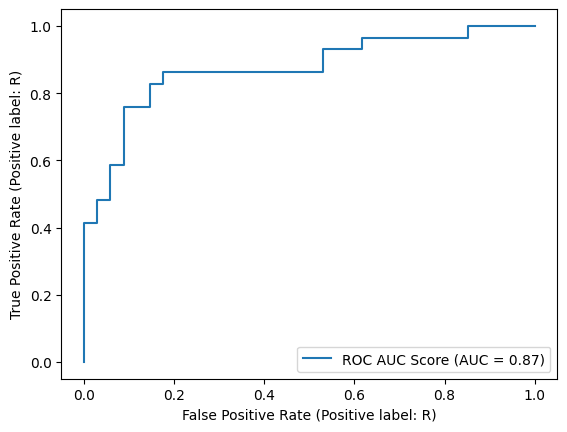

In [9]:
disp = RocCurveDisplay(fpr=fpr,tpr=tpr,estimator_name='ROC AUC Score',roc_auc=score,pos_label='R')
disp.plot()
plt.show()

In [16]:
solvers=['lbfgs','liblinear','newton-cg','newton-cholesky','sag','saga']
Cs = np.linspace(0.001,5,20)
scores = []
for s in solvers:
    for c in Cs:
        lr = LogisticRegression(solver=s,C=c)
        lr.fit(X_train,y_train)
        y_pred = lr.predict_proba(X_test)
        y_pos = y_pred[:,1]
        y_pos
        scores.append([s,c,roc_auc_score(y_test,y_pos)])


/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:35

In [17]:
df_scores = pd.DataFrame(scores,columns=['Solver','C','Score'])
df_scores.sort_values('Score',ascending=False)

,Solver,C,Score
88,sag,2.105842,0.875254
9,lbfgs,2.368947,0.875254
45,newton-cg,1.316526,0.875254
108,saga,2.105842,0.875254
105,saga,1.316526,0.875254
...,...,...,...
0,lbfgs,0.001000,0.809331
100,saga,0.001000,0.809331
80,sag,0.001000,0.809331
40,newton-cg,0.001000,0.809331
